# **Linear Regression**


## **Setup**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## **Sample Data**

In [8]:
# Example dataset

data = {        
    "Hours": [1,2,3,4,5,6,7,8,9],
    "Score": [35,40,50,55,65,70,75,80,90]
}

df = pd.DataFrame(data)

df.head()

,Hours,Score
0,1,35
1,2,40
2,3,50
3,4,55
4,5,65


## **Visualization**

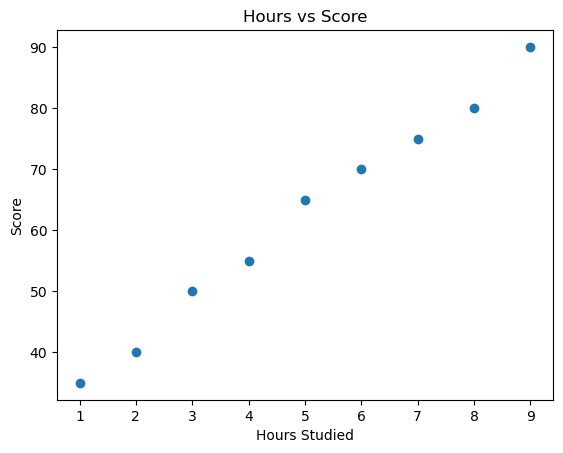

In [4]:
plt.scatter(df["Hours"], df["Score"])
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Hours vs Score")
plt.show()

## **Feature Target Split**

In [9]:
X = df[["Hours"]]
y = df["Score"]

## **Train Test Split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Training Model**

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## **Model Parameters**

In [12]:
print("Slope:", model.coef_)
print("Intercept:", model.intercept_)

Slope: [6.78571429]
Intercept: 28.928571428571438


## **Model Prediction**

In [16]:
y_pred = model.predict(X_test)
print(y_pred)

[83.21428571 42.5       ]


## **Model Evaluation**

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.857142857142847
MSE: 8.290816326530546
RMSE: 2.8793777672494705
R2 Score: 0.9792729591836736


Mathematically this represents:

𝑦 = 𝑚𝑥 + 𝑐

y=mx+c

## **Plot Regression**

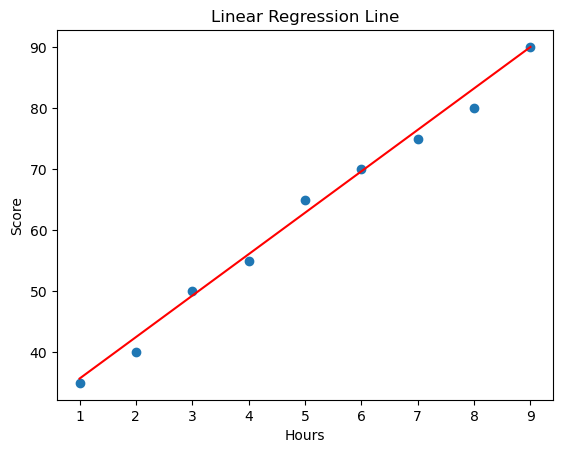

In [18]:
plt.scatter(X, y)

plt.plot(X, model.predict(X), color="red")

plt.xlabel("Hours")
plt.ylabel("Score")
plt.title("Linear Regression Line")

plt.show()

## **Multiple Linear Regression**

In [19]:
data = {
    "Area": [1000,1200,1500,1800,2000],
    "Rooms": [2,3,3,4,4],
    "Price": [200000,250000,300000,350000,400000]
}

df = pd.DataFrame(data)

X = df[["Area","Rooms"]]
y = df["Price"]

model = LinearRegression()
model.fit(X,y)

print(model.coef_)
print(model.intercept_)

[ 182.24299065 4672.89719626]
11682.242990654311


## **Normal Equation (From Scratch)**

In [20]:
X = np.array([[1,1],[1,2],[1,3]])
y = np.array([2,4,6])

theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)

print(theta)

[1.77635684e-15 2.00000000e+00]


## **Gradient Descent From Scratch**

In [21]:
X = np.array([1,2,3,4,5])
y = np.array([2,4,6,8,10])

m = 0
c = 0

lr = 0.01
epochs = 1000

n = len(X)

for i in range(epochs):

    y_pred = m*X + c
    
    dm = (-2/n) * sum(X*(y - y_pred))
    dc = (-2/n) * sum(y - y_pred)
    
    m = m - lr*dm
    c = c - lr*dc

print("Slope:",m)
print("Intercept:",c)

Slope: 1.9951803506719779
Intercept: 0.017400463340610635


## **Introduction**

### **Linear Regression**

Linear Regression is a statistical and machine learning method used to model the relationship between **input variables (X)** and a **target variable (y)**.

Basic equation:

$$
y = mx + c
$$

Where:

- \(m\) = slope
- \(c\) = intercept

### **Types of Linear Regression**

#### Simple Linear Regression

Uses **one feature**.

$$
y = \beta_0 + \beta_1 x + \epsilon
$$

- \( \beta_0 \) = intercept
- \( \beta_1 \) = slope
- \( \epsilon \) = error

### Multiple Linear Regression

Uses **multiple features**.

$$
y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon
$$

### **Matrix Representation**

Linear regression can be written as:

$$
y = X\beta + \epsilon
$$

Prediction:

$$
\hat{y} = X\beta
$$

Example matrix:

$$
X =
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
1 & x_3
\end{bmatrix}
$$

### **Matrix Representation**

Linear regression can be written as:
$$
y = X\beta + \epsilon
$$
Prediction:
$$
\hat{y} = X\beta
$$
Example matrix:
$$
X =
\begin{bmatrix}
1 & x_1 \\
1 & x_2 \\
1 & x_3
\end{bmatrix}
$$

### **Hypothesis Function**

Prediction function in machine learning:
$$
h_\theta(x) = \theta_0 + \theta_1 x
$$
Vector form:
$$
h_\theta(x) = \theta^T x
$$

### **Residual Error**

Difference between actual and predicted value.

$$
e_i = y_i - \hat{y}_i
$$

### **Cost Function**

Linear regression minimizes **Mean Squared Error (MSE)**.

$$
J(\theta) = \frac{1}{n}\sum (y_i-\hat{y}_i)^2
$$

### **Ordinary Least Squares (OLS)**

Objective:

$$
\min \sum (y_i - \hat{y}_i)^2
$$

OLS finds parameters that minimize squared errors.

### **Normal Equation**

Closed-form solution for parameters:

$$
\beta = (X^TX)^{-1}X^Ty
$$

### **Gradient Descent**
Update rule:
$$
\theta_j = \theta_j - \alpha \frac{\partial J}{\partial \theta_j}
$$
Where:
- \( \alpha \) = learning rate

### **Assumptions of Linear Regression**

1. Linearity  
2. Independence  
3. Homoscedasticity  

$$
Var(\epsilon) = constant
$$

4. Normal distribution of errors  
5. No multicollinearity

### **Evaluation Metrics**

Mean Absolute Error
$$
MAE = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$
Mean Squared Error
$$
MSE = \frac{1}{n}\sum (y_i - \hat{y}_i)^2
$$
R² Score
$$
R^2 =
1 -
\frac{\sum (y_i-\hat{y}_i)^2}
{\sum (y_i-\bar{y})^2}
$$

### **Regularization**

Ridge Regression (L2)

$$
J = MSE + \lambda \sum \beta^2
$$

Lasso Regression (L1)

$$
J = MSE + \lambda \sum |\beta|
$$

### **Bias Variance Tradeoff**

$$
Error = Bias^2 + Variance + Noise
$$

- High Bias → Underfitting
- High Variance → Overfitting

### **Polynomial Regression**
Example:
$$
y = \beta_0 + \beta_1x + \beta_2x^2
$$